In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as torchdata
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from astroML.utils import split_samples, completeness_contamination
from sklearn.metrics import roc_curve
from astropy.visualization import hist
import astropy

In [2]:
df_galaxy_quasar = pd.read_csv("galaxyquasar.csv")

1. Remember: scale your data appropriately

2. Decide on a testing strategy (a simple test/train split? a CV strategy? set a test set aside to be looked at at the very end?)

2. Decide your optimization metric.

3. Write down your network architecture. You can start from a fully connected, multi-layer perceptron (and then explore)

4. Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit-learn. This is an opportunity to pick the one you're most interested in learning. 

5. Optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best.  Do your best now to optimize the network architecture. Be creative!

6. Report on the perfomance of the network on the test set; report other metrics that have not been optimized.


In [4]:
df_galaxy_quasar
print(df_galaxy_quasar["z1"].min())
print(df_galaxy_quasar["z1"].max())
print(df_galaxy_quasar["class"])

-0.0007908334
6.991177
0           QSO
1        GALAXY
2        GALAXY
3        GALAXY
4           QSO
          ...  
49995    GALAXY
49996    GALAXY
49997    GALAXY
49998    GALAXY
49999    GALAXY
Name: class, Length: 50000, dtype: object


In [5]:
u = df_galaxy_quasar["u"]
g = df_galaxy_quasar["g"]
r = df_galaxy_quasar["r"]
i = df_galaxy_quasar["i"]
z = df_galaxy_quasar["z"]
#############################################
UmG = u-g
GmR = g-r 
RmI = r-i 
Imz = i-z 

In [6]:
X = np.array([UmG,GmR,RmI,Imz])
CLASS = df_galaxy_quasar["class"]
y = np.array(df_galaxy_quasar["class"]=="QSO", dtype=int)

In [7]:
(X_train_full, X_test), (y_train_full, y_test) = split_samples(X.T, y, [0.80, 0.20], random_state=42)

In [8]:
print(len(X_train_full))

40000


In [9]:
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:] 
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

#riscale data
X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[:, :, np.newaxis]
X_valid = X_valid[:,  :, np.newaxis]
X_test = X_test[:, :, np.newaxis]

print(len(X_train))
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

35000
(35000, 4, 1)
(5000, 4, 1)
(10000, 4, 1)


In [18]:
keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tf.random.set_seed(42)

In [20]:
model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=64, kernel_size=7, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=2),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling1D(pool_size=1),
    keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    keras.layers.Conv1D(256, 3, activation='relu', padding='same'),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [22]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 64)          │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2, 128)         │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 2, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,490 (1.70 MB)

 Trainable params: 444,490 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

None


In [50]:
#### This may take a while! Hopefully no more than 5 minutes for 1 epoch.
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
clf = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

Epoch 1/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9861 - loss: 0.0551 - val_accuracy: 0.9846 - val_loss: 0.0531
Epoch 2/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9862 - loss: 0.0519 - val_accuracy: 0.9844 - val_loss: 0.0558
Epoch 3/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9856 - loss: 0.0513 - val_accuracy: 0.9844 - val_loss: 0.0564
Epoch 4/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9862 - loss: 0.0503 - val_accuracy: 0.9842 - val_loss: 0.0558
Epoch 5/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9857 - loss: 0.0520 - val_accuracy: 0.9840 - val_loss: 0.0597
Epoch 6/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9861 - loss: 0.0489 - val_accuracy: 0.9836 - val_loss: 0.0596
Epoch 7/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.9864 - loss: 0.0515 - val_accuracy: 0.9834 - val_loss: 0.0734
Epoch 8/30
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9862 -

In [51]:
y_prob = model.predict(X_test).round(2)[:,1]
print(y_prob)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
[0.   0.99 0.   ... 0.   0.   1.  ]


Text(0, 0.5, 'True Positive Rate')

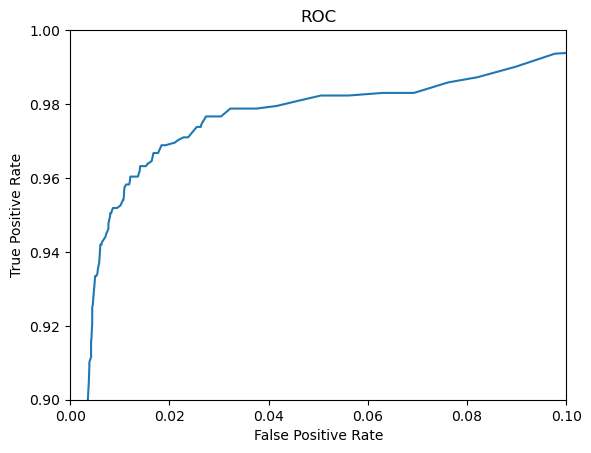

In [52]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title("ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

In [60]:
y_pred = np.argmax(model.predict(X_test), axis=-1)
print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
[0 1 0 ... 0 0 1]


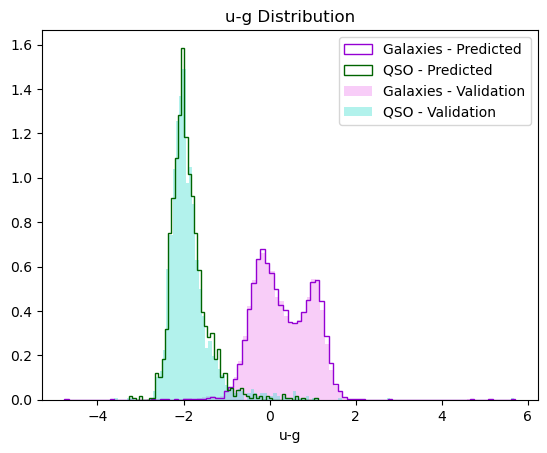

In [62]:
X_slice = X_test[:, 0]
y_test_slice = y_test
y_pred_slice = y_pred

astropy.visualization.hist(X_slice[y_pred_slice == 0], bins="freedman", histtype="step", density=True,
                           color="darkviolet", label="Galaxies - Predicted")
astropy.visualization.hist(X_slice[y_pred_slice == 1], bins="freedman", histtype="step", density=True,
                           color="darkgreen", label="QSO - Predicted")

astropy.visualization.hist(X_slice[y_test_slice == 0], bins="freedman", histtype="stepfilled",density=True,
                           alpha=0.4, color="violet", label="Galaxies - Validation")
astropy.visualization.hist(X_slice[y_test_slice == 1], bins="freedman", histtype="stepfilled",density=True,
                        alpha=0.4, color="turquoise", label="QSO - Validation")

#plt.xlim(-1, 3)
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.legend(loc="upper right")
plt.show()

In [64]:
model1 = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[4, 1]),
    keras.layers.Conv1D(filters=32, kernel_size=7, activation='relu', padding='same'),
    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [66]:
print(model1.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 4, 32)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,162 (35.79 KB)

 Trainable params: 9,162 (35.79 KB)

 Non-trainable params: 0 (0.00 B)

None


In [68]:
#### This may take a while! Hopefully no more than 5 minutes for 1 epoch.
model1.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
clf1 = model1.fit(X_train, y_train, epochs=15, validation_data=(X_valid, y_valid))

Epoch 1/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9532 - loss: 0.2088 - val_accuracy: 0.9804 - val_loss: 0.0812
Epoch 2/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9792 - loss: 0.0907 - val_accuracy: 0.9826 - val_loss: 0.0697
Epoch 3/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9804 - loss: 0.0818 - val_accuracy: 0.9824 - val_loss: 0.0666
Epoch 4/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9811 - loss: 0.0788 - val_accuracy: 0.9824 - val_loss: 0.0673
Epoch 5/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9819 - loss: 0.0752 - val_accuracy: 0.9838 - val_loss: 0.0634
Epoch 6/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9820 - loss: 0.0745 - val_accuracy: 0.9846 - val_loss: 0.0592
Epoch 7/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9819 - loss: 0.0721 - val_accuracy: 0.9830 - val_loss: 0.0602
Epoch 8/15
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9833 - loss: 0.0674 -

In [70]:
y_prob = model1.predict(X_test).round(2)[:,1]
print(y_prob)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[0.   0.99 0.   ... 0.   0.   1.  ]


In [74]:
y_pred = np.argmax(model1.predict(X_test), axis=-1)
print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[0 1 0 ... 0 0 1]


Text(0, 0.5, 'True Positive Rate')

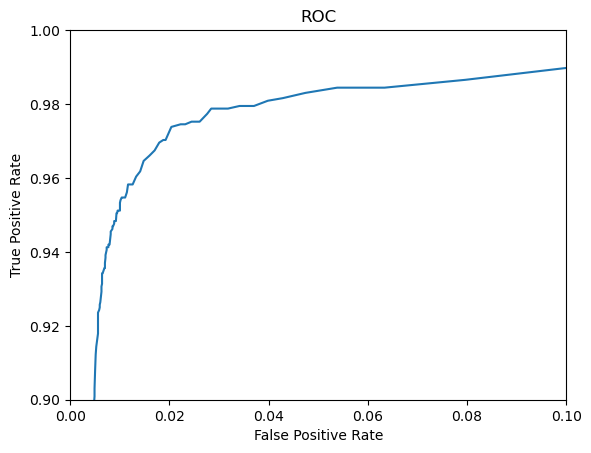

In [76]:
fpr, tpr, thresh = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlim(0,0.1)
plt.ylim(0.9,1)
plt.title("ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

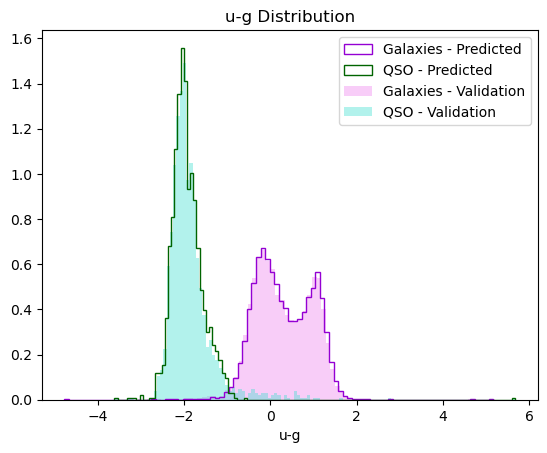

In [84]:
X_slice = X_test[:,0]
y_test_slice = y_test
y_pred_slice = y_pred

astropy.visualization.hist(X_slice[y_pred_slice == 0], bins="freedman", histtype="step", 
                           color="darkviolet", density=True, label="Galaxies - Predicted")
astropy.visualization.hist(X_slice[y_pred_slice == 1], bins="freedman", histtype="step", 
                           color="darkgreen", density=True, label="QSO - Predicted")

astropy.visualization.hist(X_slice[y_test_slice == 0], bins="freedman", histtype="stepfilled",
                           density=True, alpha=0.4, color="violet", label="Galaxies - Validation")
astropy.visualization.hist(X_slice[y_test_slice == 1], bins="freedman", histtype="stepfilled",
                           density=True, alpha=0.4, color="turquoise", label="QSO - Validation")

#plt.xlim(-1, 3)
plt.title("u-g Distribution")
plt.xlabel('u-g')
plt.legend(loc="upper right")
plt.show()